# Neural Networks with Keras (Sequential API)

This notebook introduces building neural networks using Keras.

We will:

- Build a neural network using the Sequential API
- Train the model using backpropagation
- Understand loss functions and optimizers
- Evaluate model performance

---

## Objective

Transition from manual ML models to modern deep learning frameworks.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

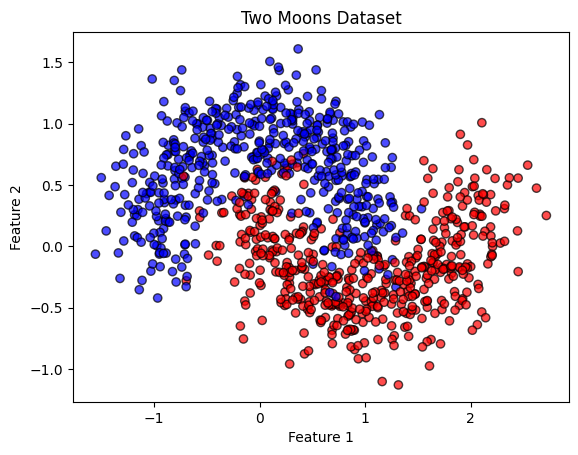

In [15]:
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

plt.Figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k", alpha=0.7)

plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
X_train.shape[1:]

(2,)

In [19]:
model = keras.Sequential([
    keras.Input(shape=X_train.shape[1:]),
    keras.layers.Dense(20, activation="relu"),
    keras.layers.Dense(20, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

In [20]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    verbose=2
)

Epoch 1/20
19/19 - 1s - 53ms/step - accuracy: 0.5050 - loss: 0.6359 - val_accuracy: 0.6333 - val_loss: 0.5590
Epoch 2/20
19/19 - 0s - 4ms/step - accuracy: 0.7167 - loss: 0.5554 - val_accuracy: 0.8333 - val_loss: 0.4912
Epoch 3/20
19/19 - 0s - 4ms/step - accuracy: 0.8217 - loss: 0.4937 - val_accuracy: 0.8533 - val_loss: 0.4348
Epoch 4/20
19/19 - 0s - 4ms/step - accuracy: 0.8400 - loss: 0.4433 - val_accuracy: 0.8533 - val_loss: 0.3899
Epoch 5/20
19/19 - 0s - 4ms/step - accuracy: 0.8450 - loss: 0.4030 - val_accuracy: 0.8533 - val_loss: 0.3559
Epoch 6/20
19/19 - 0s - 4ms/step - accuracy: 0.8550 - loss: 0.3733 - val_accuracy: 0.8533 - val_loss: 0.3291
Epoch 7/20
19/19 - 0s - 4ms/step - accuracy: 0.8567 - loss: 0.3519 - val_accuracy: 0.8667 - val_loss: 0.3089
Epoch 8/20
19/19 - 0s - 5ms/step - accuracy: 0.8600 - loss: 0.3377 - val_accuracy: 0.8667 - val_loss: 0.2947
Epoch 9/20
19/19 - 0s - 4ms/step - accuracy: 0.8600 - loss: 0.3299 - val_accuracy: 0.8667 - val_loss: 0.2848
Epoch 10/20
19/19 

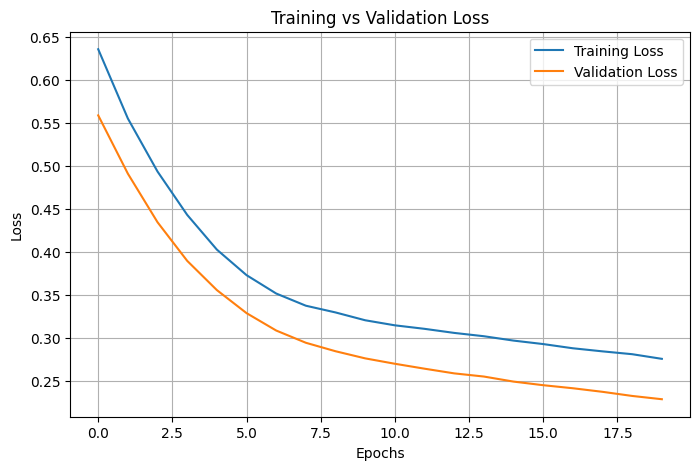

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()
plt.show()

In [23]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8960 - loss: 0.2364 
Test Accuracy: 0.8960000276565552


In [24]:
predictions = model.predict(X_test[:5])

print("Predictions:", predictions)
print("Actual:", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predictions: [[0.9580944 ]
 [0.4393128 ]
 [0.95162505]
 [0.07243829]
 [0.9854427 ]]
Actual: [1 0 1 0 1]


## Interpretation

The neural network successfully learns a nonlinear decision boundary.

Key observations:

- Loss decreases over epochs → learning is happening
- Validation loss indicates generalization
- Adam optimizer ensures stable and fast convergence

---

## Key Insight

Keras abstracts:

- Forward pass
- Backpropagation
- Gradient updates

allowing us to focus on **model design and experimentation**.